In [1]:
#imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc

from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
#Read Datasets

#NSL-KDD
nsl_train = pd.read_csv('E:/Datasets/NSL-KDD/KDDTrain+.txt')
nsl_test = pd.read_csv('E:/Datasets/NSL-KDD/KDDTest+.txt')
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

nsl_train.columns = columns
nsl_test.columns = columns

df_nsl = pd.concat([nsl_train, nsl_test])

# # map normal to 0, all attacks to 1
# is_attack = df_nsl.attack.map(lambda a: 0 if a == 'normal' else 1)
# #test_attack = test_df.attack.map(lambda a: 0 if a == 'normal' else 1)

# #data_with_attack = df.join(is_attack, rsuffix='_flag')
# df_nsl['label'] = is_attack
# #test_df['attack_flag'] = test_attack

# lists to hold our attack classifications
dos_attacks = ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm']
probe_attacks = ['ipsweep','mscan','nmap','portsweep','saint','satan']
privilege_attacks = ['buffer_overflow','loadmdoule','perl','ps','rootkit','sqlattack','xterm']
access_attacks = ['ftp_write','guess_passwd','http_tunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xclock','xsnoop']

# we will use these for plotting below
attack_labels = ['Normal','DoS','Probe','U2R','R2L']

# helper function to pass to data frame mapping
def map_attack(attack):
    if attack in dos_attacks:
        # dos_attacks map to 1
        attack_type = 'DoS'
    elif attack in probe_attacks:
        # probe_attacks mapt to 2
        attack_type = 'Probe'
    elif attack in privilege_attacks:
        # privilege escalation attacks map to 3
        attack_type = 'U2R'
    elif attack in access_attacks:
        # remote access attacks map to 4
        attack_type = 'R2L'
    else:
        # normal maps to 0
        attack_type = 'Normal'
        
    return attack_type

# map the data and join to the data set
attack_map = df_nsl.attack.apply(map_attack)
df_nsl['attack_map'] = attack_map

total = df_nsl.shape[0]
missing_columns = [col for col in df_nsl.columns if df_nsl[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_nsl[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

print(f"Number of duplicate rows: {df_nsl.duplicated().sum()}")

df_nsl.replace([np.inf, -np.inf], np.nan, inplace=True)

df_nsl = df_nsl.dropna()
df_nsl.isnull().values.any()

df_nsl.drop_duplicates(keep=False, inplace=True)

list_drop = ['level', 'attack']
df_nsl.drop(list_drop, axis=1,inplace=True)

# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])
# le(df_nsl)


df_nsl = df_nsl.dropna()
df_nsl.isnull().values.any()

df_nsl.drop_duplicates(keep=False, inplace=True)


Number of duplicate rows: 610


In [3]:
#UNSW-NB15

unsw_train = pd.read_csv("E:/Datasets/UNSWNB15/CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv")
unsw_test = pd.read_csv("E:/Datasets/UNSWNB15/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")

df_unsw = pd.concat([unsw_train, unsw_test])

list_drop = ['id','label']
df_unsw.drop(list_drop,axis=1,inplace=True)

# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])
# le(df_unsw)

In [4]:
#CIC-IDS2017

df_cicids = pd.read_csv("E:/Datasets/CICIDS2017/combined_file.csv")

df_cicids.columns = df_cicids.columns.str.replace(' ', '')

# # map normal to 0, all attacks to 1
# is_attack = df_cicids.Label.map(lambda a: 0 if a == 'BENIGN' else 1)
# #test_attack = test_df.attack.map(lambda a: 0 if a == 'normal' else 1)

# #data_with_attack = df.join(is_attack, rsuffix='_flag')
# df_cicids['label'] = is_attack

total = df_cicids.shape[0]
missing_columns = [col for col in df_cicids.columns if df_cicids[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_cicids[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")


df_cicids.isnull().values.any()

df_cicids.replace([np.inf, -np.inf], np.nan, inplace=True)

df_cicids = df_cicids.dropna()
df_cicids.isnull().values.any()

#df_cicids.drop(['Label'],axis=1,inplace=True)

# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])
# le(df_cicids)

FlowBytes/s: 1358 (0.048%)


False

In [5]:
#CSE-CIC-IDS2018

df_csecic = pd.read_csv("F:/Datasets/CSE-CIC-IDS2018/CSE-CIC-IDS2018.csv", low_memory=False)

total = df_csecic.shape[0]
missing_columns = [col for col in df_csecic.columns if df_csecic[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_csecic[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")


df_csecic.isnull().values.any()

df_csecic.replace([np.inf, -np.inf], np.nan, inplace=True)

df_csecic = df_cicids.dropna()
df_csecic.isnull().values.any()

Flow Byts/s: 59721 (0.368%)
Flow ID: 8284254 (51.033%)
Src IP: 8284254 (51.033%)
Src Port: 8284254 (51.033%)
Dst IP: 8284254 (51.033%)


False

In [9]:
#ToN-IoT

df_ton = pd.read_csv("F:/Datasets/Ton_IoT/train_test_network.csv")

total = df_ton.shape[0]
missing_columns = [col for col in df_ton.columns if df_ton[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_ton[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")


df_ton.isnull().values.any()

df_ton.replace([np.inf, -np.inf], np.nan, inplace=True)

df_ton = df_ton.dropna()
df_ton.isnull().values.any()

df_ton.drop(['label'],axis=1,inplace=True)


# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])
# le(df_ton)

# df_ton = df_ton.dropna()
# df_ton.isnull().values.any()

#df_ton.drop_duplicates(keep=False, inplace=True)

In [11]:
#Bot-IoT

df_1 = pd.read_csv("F:/Datasets/Bot_IoT/5pc/UNSW_2018_IoT_Botnet_Full5pc_1.csv", low_memory=False)
df_2 = pd.read_csv("F:/Datasets/Bot_IoT/5pc/UNSW_2018_IoT_Botnet_Full5pc_2.csv", low_memory=False)
df_3 = pd.read_csv("F:/Datasets/Bot_IoT/5pc/UNSW_2018_IoT_Botnet_Full5pc_3.csv", low_memory=False)
df_4 = pd.read_csv("F:/Datasets/Bot_IoT/5pc/UNSW_2018_IoT_Botnet_Full5pc_4.csv", low_memory=False)

df_12 = pd.concat([df_1, df_2,])
df_34 = pd.concat([df_3, df_4])
df_bot = pd.concat([df_12, df_34])

total = df_bot.shape[0]
missing_columns = [col for col in df_bot.columns if df_bot[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_bot[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")


df_bot.isnull().values.any()

df_bot.replace([np.inf, -np.inf], np.nan, inplace=True)

df_bot = df_bot.dropna()
df_bot.isnull().values.any()


list_drop = ['subcategory']
df_bot.drop(list_drop, axis=1,inplace=True)

# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])
# le(df_bot)

In [13]:
#HIKARI-2021

df_hikari = pd.read_csv("E:/Datasets/HIKARI2021/ALLFLOWMETER_HIKARI2021.csv")

total = df_hikari.shape[0]
missing_columns = [col for col in df_hikari.columns if df_hikari[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_hikari[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

df_hikari.replace([np.inf, -np.inf], np.nan, inplace=True)

df_hikari = df_hikari.dropna()
df_hikari.isnull().values.any()

df_hikari.drop(['Label'],axis=1,inplace=True)



In [14]:
#UNR-IDD

df_unr = pd.read_csv("F:/Datasets/UNR-IDD/UNR-IDD.csv")


total = df_unr.shape[0]
missing_columns = [col for col in df_unr.columns if df_unr[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = df_unr[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

df_unr.replace([np.inf, -np.inf], np.nan, inplace=True)

df_unr = df_unr.dropna()
df_unr.isnull().values.any()

list_drop = ['Binary Label']
df_unr.drop(list_drop, axis=1,inplace=True)

# def le(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#                 label_encoder = LabelEncoder()
#                 df[col] = label_encoder.fit_transform(df[col])

# le(df_unr)

In [15]:
DATASETS = {
    "NSL-KDD": {
        "df": df_nsl,
        "label_col": "attack_map"
    },
    "UNSW-NB15": {
        "df": df_unsw,
        "label_col": "attack_cat"
    },
    "CIC-IDS2017": {
        "df": df_cicids,
        "label_col": "Label"
    },
    "CSE-CIC-IDS2018": {
        "df": df_csecic,
        "label_col": "Label"
    },
    "BoT-IoT": {
        "df": df_bot,
        "label_col": "category"
    },
    "ToN-IoT": {
        "df": df_ton,
        "label_col": "type"
    },
    "HIKARI-2021": {
        "df": df_hikari,
        "label_col": "traffic_category"
    },
    "UNR-IDD": {
        "df": df_unr,
        "label_col": "Label"
    }
}

print("Dataset dictionary created successfully")


Dataset dictionary created successfully


In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, average_precision_score

results = []

for name, config in DATASETS.items():

    print(f"\nProcessing {name}")

    df = config["df"].copy()
    label_col = config["label_col"]

    X = df.drop(columns=[label_col])
    y = df[label_col].astype(str)

    # Encode categorical features
    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # Encode labels to integers
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    classes = np.unique(y_encoded)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y_encoded,
        test_size=0.3,
        stratify=y_encoded,
        random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Macro F1
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Binarize labels for PR-AUC
    y_test_bin = label_binarize(y_test, classes=classes)

    # Macro PR-AUC (One-vs-Rest)
    macro_pr_auc = average_precision_score(
        y_test_bin,
        y_prob,
        average='macro'
    )

    print(f"Macro PR-AUC: {macro_pr_auc:.4f}, Macro F1: {macro_f1:.4f}")

    results.append({
        "Dataset": name,
        "Macro_PR-AUC": macro_pr_auc,
        "Macro_F1": macro_f1
    })

performance_df = pd.DataFrame(results)

performance_df


Processing NSL-KDD
Macro PR-AUC: 0.9305, Macro F1: 0.8999

Processing UNSW-NB15
Macro PR-AUC: 0.6151, Macro F1: 0.5618

Processing CIC-IDS2017
Macro PR-AUC: 0.9042, Macro F1: 0.8575

Processing CSE-CIC-IDS2018
Macro PR-AUC: 0.9042, Macro F1: 0.8575

Processing BoT-IoT
Macro PR-AUC: 1.0000, Macro F1: 1.0000

Processing ToN-IoT
Macro PR-AUC: 0.9961, Macro F1: 0.9860

Processing HIKARI-2021
Macro PR-AUC: 1.0000, Macro F1: 0.9996

Processing UNR-IDD
Macro PR-AUC: 0.9843, Macro F1: 0.9359


,Dataset,Macro_PR-AUC,Macro_F1
0,NSL-KDD,0.930535,0.899860
1,UNSW-NB15,0.615146,0.561806
2,CIC-IDS2017,0.904221,0.857471
3,CSE-CIC-IDS2018,0.904221,0.857471
4,BoT-IoT,1.000000,1.000000
5,ToN-IoT,0.996113,0.986035
6,HIKARI-2021,0.999999,0.999606
7,UNR-IDD,0.984261,0.935895


In [18]:
performance_df.to_csv("ids_performance_results.csv", index=False)

print("Performance results saved")

Performance results saved


In [19]:
framework_df = pd.read_csv("framework_scores.csv")

framework_df

,Dataset,ATC,AS,FCPA,PDR,CIS,TRI
0,NSL-KDD,0.4226,0.2264,0.5952,0.728092,0.634779,0.517023
1,UNSW-NB15,0.3916,0.3671,0.5536,0.729147,0.854908,0.457623
2,CIC-IDS2017,0.3449,0.2037,0.3524,0.598785,0.779950,0.477142
3,CSE-CIC-IDS2018,0.3102,0.1923,0.7143,0.636033,0.630695,0.479349
4,ToN-IoT,0.2845,0.1387,0.6429,0.656423,0.543060,0.531016
5,BoT-IoT,0.2625,0.1645,0.5071,0.817848,0.632958,0.430933
6,HIKARI-2021,0.2397,0.2290,0.6429,0.701781,0.559353,0.528349
7,UNR-IDD,0.2301,0.1994,0.6333,NaN,0.832675,0.760132


In [63]:
import os
os.makedirs("validation_results/figures", exist_ok=True)

In [20]:
merged_df = framework_df.merge(performance_df, on="Dataset")

merged_df

,Dataset,ATC,AS,FCPA,PDR,CIS,TRI,Macro_PR-AUC,Macro_F1
0,NSL-KDD,0.4226,0.2264,0.5952,0.728092,0.634779,0.517023,0.930535,0.899860
1,UNSW-NB15,0.3916,0.3671,0.5536,0.729147,0.854908,0.457623,0.615146,0.561806
2,CIC-IDS2017,0.3449,0.2037,0.3524,0.598785,0.779950,0.477142,0.904221,0.857471
3,CSE-CIC-IDS2018,0.3102,0.1923,0.7143,0.636033,0.630695,0.479349,0.904221,0.857471
4,ToN-IoT,0.2845,0.1387,0.6429,0.656423,0.543060,0.531016,0.996113,0.986035
5,BoT-IoT,0.2625,0.1645,0.5071,0.817848,0.632958,0.430933,1.000000,1.000000
6,HIKARI-2021,0.2397,0.2290,0.6429,0.701781,0.559353,0.528349,0.999999,0.999606
7,UNR-IDD,0.2301,0.1994,0.6333,NaN,0.832675,0.760132,0.984261,0.935895


In [65]:
merged_df.to_csv(
    "validation_results/merged_metrics_performance.csv",
    index=False
)

In [22]:
# Remove rows where PDR is NaN
pdr_subset = merged_df.dropna(subset=["PDR"])

pdr_subset[["Dataset", "PDR", "Macro_PR-AUC", "Macro_F1"]]

,Dataset,PDR,Macro_PR-AUC,Macro_F1
0,NSL-KDD,0.728092,0.930535,0.899860
1,UNSW-NB15,0.729147,0.615146,0.561806
2,CIC-IDS2017,0.598785,0.904221,0.857471
3,CSE-CIC-IDS2018,0.636033,0.904221,0.857471
4,ToN-IoT,0.656423,0.996113,0.986035
5,BoT-IoT,0.817848,1.000000,1.000000
6,HIKARI-2021,0.701781,0.999999,0.999606


In [23]:
from scipy.stats import spearmanr

corr_pr_pdr, _ = spearmanr(
    pdr_subset["PDR"],
    pdr_subset["Macro_PR-AUC"]
)

corr_f1_pdr, _ = spearmanr(
    pdr_subset["PDR"],
    pdr_subset["Macro_F1"]
)

print("Spearman (PDR vs Macro_PR-AUC):", corr_pr_pdr)
print("Spearman (PDR vs Macro_F1):", corr_f1_pdr)

Spearman (PDR vs Macro_PR-AUC): 0.3571428571428572
Spearman (PDR vs Macro_F1): 0.34235623582431246


In [24]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

metrics = ["ATC", "AS", "FCPA", "PDR", "CIS", "TRI"]

correlation_results = []

for metric in metrics:

    # Drop rows where either metric or performance is NaN
    subset = merged_df.dropna(subset=[metric, "Macro_PR-AUC", "Macro_F1"])

    # Compute Spearman correlations
    corr_pr, _ = spearmanr(subset[metric], subset["Macro_PR-AUC"])
    corr_f1, _ = spearmanr(subset[metric], subset["Macro_F1"])

    correlation_results.append({
        "Metric": metric,
        "Spearman(Macro_PR-AUC)": corr_pr, 
        "Spearman(Macro_F1)": corr_f1,
        "Datasets_used": len(subset)
    })

correlation_df = pd.DataFrame(correlation_results)

correlation_df

,Metric,Spearman(Macro_PR-AUC),Spearman(Macro_F1),Datasets_used
0,ATC,-0.690476,-0.682647,8
1,AS,-0.476190,-0.455098,8
2,FCPA,0.203596,0.120482,8
3,PDR,0.357143,0.342356,7
4,CIS,-0.619048,-0.586837,8
5,TRI,0.238095,0.227549,8


In [67]:
correlation_df.to_csv("validation_results/correlation_results.csv", index=False)

print("Correlation results saved")

Correlation results saved


In [49]:
!pip install adjusttext

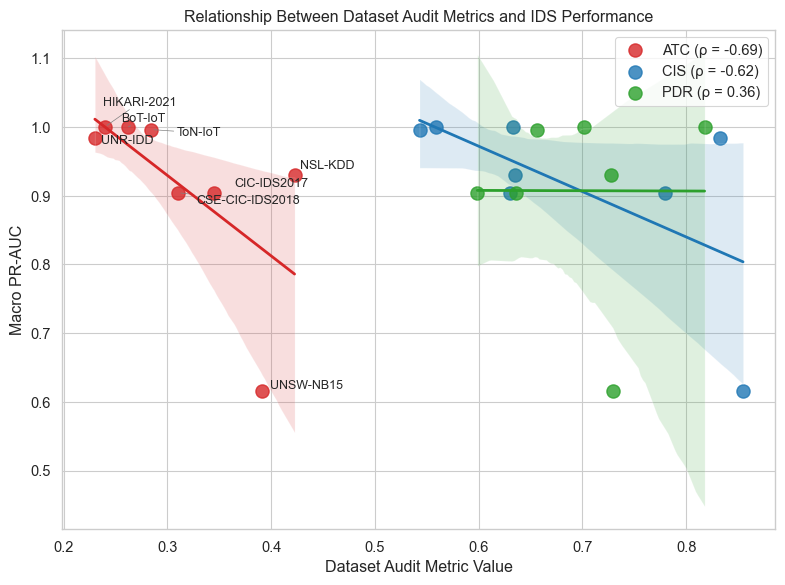

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from adjustText import adjust_text

sns.set(style="whitegrid", context="paper", font_scale=1.2)

fig, ax = plt.subplots(figsize=(8,6))

# Compute correlations
rho_atc, _ = spearmanr(merged_df["ATC"], merged_df["Macro_PR-AUC"])
rho_cis, _ = spearmanr(merged_df["CIS"], merged_df["Macro_PR-AUC"])

pdr_subset = merged_df.dropna(subset=["PDR"])
rho_pdr, _ = spearmanr(pdr_subset["PDR"], pdr_subset["Macro_PR-AUC"])

# Plot regression relationships
sns.regplot(
    x="ATC",
    y="Macro_PR-AUC",
    data=merged_df,
    color="#d62728",
    scatter_kws={"s":90},
    line_kws={"linewidth":2},
    label=f"ATC (ρ = {rho_atc:.2f})",
    ax=ax
)

sns.regplot(
    x="CIS",
    y="Macro_PR-AUC",
    data=merged_df,
    color="#1f77b4",
    scatter_kws={"s":90},
    line_kws={"linewidth":2},
    label=f"CIS (ρ = {rho_cis:.2f})",
    ax=ax
)

sns.regplot(
    x="PDR",
    y="Macro_PR-AUC",
    data=pdr_subset,
    color="#2ca02c",
    scatter_kws={"s":90},
    line_kws={"linewidth":2},
    label=f"PDR (ρ = {rho_pdr:.2f})",
    ax=ax
)

# Add dataset labels
texts = []
for i, row in merged_df.iterrows():
    texts.append(
        ax.text(
            row["ATC"],
            row["Macro_PR-AUC"],
            row["Dataset"],
            fontsize=9
        )
    )

# Automatically adjust labels to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    ax=ax
)

ax.set_xlabel("Dataset Audit Metric Value")
ax.set_ylabel("Macro PR-AUC")
ax.set_title("Relationship Between Dataset Audit Metrics and IDS Performance")

ax.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "validation_results/figures/dataset_audit_metrics_vs_ids_performance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [55]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, norm

metrics = ["ATC", "AS", "FCPA", "PDR", "CIS", "TRI"]

results = []

def fisher_ci(r, n, alpha=0.05):
    """Compute Fisher z confidence interval for correlation"""
    if n <= 3:
        return (np.nan, np.nan)

    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha/2)

    lo = z - z_crit * se
    hi = z + z_crit * se

    return (np.tanh(lo), np.tanh(hi))


for metric in metrics:

    # Remove rows where metric is missing
    subset = merged_df.dropna(subset=[metric, "Macro_PR-AUC"])

    x = subset[metric]
    y = subset["Macro_PR-AUC"]

    rho, pval = spearmanr(x, y)

    n = len(subset)

    ci_low, ci_high = fisher_ci(rho, n)

    results.append({
        "Metric": metric,
        "rho": rho,
        "p_value": pval,
        "CI_lower": ci_low,
        "CI_upper": ci_high,
        "n": n
    })

correlation_table = pd.DataFrame(results)

print("=== Primary Correlation Results ===")
display(correlation_table)



# -----------------------------
# Robustness Check
# -----------------------------

excluded_datasets = ["BoT-IoT", "ToN-IoT", "HIKARI-2021"]

robust_df = merged_df[~merged_df["Dataset"].isin(excluded_datasets)]

robust_results = []

for metric in metrics:

    subset = robust_df.dropna(subset=[metric, "Macro_PR-AUC"])

    x = subset[metric]
    y = subset["Macro_PR-AUC"]

    rho, pval = spearmanr(x, y)

    n = len(subset)

    ci_low, ci_high = fisher_ci(rho, n)

    robust_results.append({
        "Metric": metric,
        "rho": rho,
        "p_value": pval,
        "CI_lower": ci_low,
        "CI_upper": ci_high,
        "n": n
    })

robust_table = pd.DataFrame(robust_results)

print("\n=== Robustness Check (excluding BoT-IoT, ToN-IoT, HIKARI-2021) ===")
display(robust_table)

=== Primary Correlation Results ===


,Metric,rho,p_value,CI_lower,CI_upper,n
0,ATC,-0.690476,0.057990,-0.938509,0.027650,8
1,AS,-0.476190,0.232936,-0.884172,0.343871,8
2,FCPA,0.203596,0.628675,-0.585007,0.794311,8
3,PDR,0.357143,0.431611,-0.541570,0.874898,7
4,CIS,-0.619048,0.101733,-0.921666,0.151879,8
5,TRI,0.238095,0.570156,-0.560642,0.807317,8



=== Robustness Check (excluding BoT-IoT, ToN-IoT, HIKARI-2021) ===


,Metric,rho,p_value,CI_lower,CI_upper,n
0,ATC,-0.4,5.046316e-01,-0.947786,0.745281,5
1,AS,-0.5,3.910022e-01,-0.959152,0.684003,5
2,FCPA,0.6,2.847570e-01,-0.599750,0.969207,5
3,PDR,-0.2,8.000000e-01,-0.973889,0.942193,4
4,CIS,-0.3,6.238377e-01,-0.934834,0.791854,5
5,TRI,1.0,1.404265e-24,1.000000,1.000000,5


In [73]:
robustness_df = pd.DataFrame(robust_results)

robustness_df.to_csv(
    "validation_results/robustness_exclusion_results.csv",
    index=False)

In [75]:
correlation_table.to_csv("validation_results/primary_correlation_results.csv",
    index=False)

In [59]:
#Weight Sensitivity Analysis

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

np.random.seed(42)

metrics_to_test = ["ATC", "AS", "CIS"]

results = []

for metric in metrics_to_test:

    base_scores = merged_df[metric]
    base_rank = base_scores.rank(ascending=False)

    correlations = []

    for i in range(1000):

        # perturb each dataset independently ±10%
        noise = np.random.uniform(0.9, 1.1, size=len(base_scores))

        perturbed_scores = base_scores * noise

        perturbed_rank = pd.Series(perturbed_scores).rank(ascending=False)

        rho, _ = spearmanr(base_rank, perturbed_rank)

        correlations.append(rho)

    results.append({
        "Metric": metric,
        "Mean_rank_correlation": np.mean(correlations),
        "Min_rank_correlation": np.min(correlations),
        "Max_rank_correlation": np.max(correlations)
    })

sensitivity_df = pd.DataFrame(results)

display(sensitivity_df)

,Metric,Mean_rank_correlation,Min_rank_correlation,Max_rank_correlation
0,ATC,0.967833,0.880952,1.0
1,AS,0.946214,0.714286,1.0
2,CIS,0.910024,0.666667,1.0


In [61]:
#weight perturbation analysis for ATC metric

import pandas as pd
from scipy.stats import spearmanr

# create dataframe from your stored component values
df = pd.DataFrame({
    "Dataset": [
        "NSL-KDD","ToN-IoT","UNSW-NB15","HIKARI-2021",
        "CIC-IDS2017","BoT-IoT","CSE-CIC-IDS2018","UNR-IDD"
    ],
    "Breadth": [0.7843,0.6978,0.5556,0.4421,0.4248,0.3165,0.2941,0.2254],
    "TechniqueCov": [0.0146,0.0086,0.0061,0.011,0.0069,0.0034,0.0046,0.0185],
    "Evenness": [0.9384,0.9534,0.9826,1,0.8824,1,0.8962,0.9464]
})

# original weight configuration
weights = {
    "Original": (0.35, 0.50, 0.15),

    # supervisor-style perturbations
    "Alt1": (0.25, 0.60, 0.15),
    "Alt2": (0.45, 0.40, 0.15),

    # evenness emphasis variation
    "Alt3": (0.35, 0.40, 0.25),
    "Alt4": (0.40, 0.45, 0.15)
}

# compute ATC scores under each configuration
for name,(a,b,c) in weights.items():

    df[f"ATC_{name}"] = (
        a*df["Breadth"]
        + b*df["TechniqueCov"]
        + c*df["Evenness"]
    )

# compute ranking stability
base_rank = df["ATC_Original"].rank(ascending=False)

results = []

for name in weights:

    rank = df[f"ATC_{name}"].rank(ascending=False)

    rho,_ = spearmanr(base_rank, rank)

    results.append({
        "Configuration": name,
        "alpha": weights[name][0],
        "beta": weights[name][1],
        "gamma": weights[name][2],
        "Rank_correlation_vs_original": rho
    })

results_df = pd.DataFrame(results)

print("\nATC Weight Sensitivity Results")
display(results_df)

# optional: show ranking changes
ranking_table = df[["Dataset"] + [f"ATC_{k}" for k in weights]]
ranking_table = ranking_table.sort_values("ATC_Original", ascending=False)

print("\nDataset Rankings Under Different Weight Sets")
display(ranking_table)


ATC Weight Sensitivity Results


,Configuration,alpha,beta,gamma,Rank_correlation_vs_original
0,Original,0.35,0.50,0.15,1.0
1,Alt1,0.25,0.60,0.15,1.0
2,Alt2,0.45,0.40,0.15,1.0
3,Alt3,0.35,0.40,0.25,1.0
4,Alt4,0.40,0.45,0.15,1.0



Dataset Rankings Under Different Weight Sets


,Dataset,ATC_Original,ATC_Alt1,ATC_Alt2,ATC_Alt3,ATC_Alt4
0,NSL-KDD,0.422565,0.345595,0.499535,0.514945,0.461050
1,ToN-IoT,0.391540,0.322620,0.460460,0.486020,0.426000
2,UNSW-NB15,0.344900,0.289950,0.399850,0.442550,0.372375
3,HIKARI-2021,0.310235,0.267125,0.353345,0.409135,0.331790
4,CIC-IDS2017,0.284490,0.242700,0.326280,0.372040,0.305385
5,BoT-IoT,0.262475,0.231165,0.293785,0.362135,0.278130
6,CSE-CIC-IDS2018,0.239665,0.210715,0.268615,0.328825,0.254140
7,UNR-IDD,0.230100,0.209410,0.250790,0.322890,0.240445


In [77]:
results_df.to_csv("validation_results/atc_weight_sensitivity_results.csv",
    index=False
)
print("\nATC Weight Sensitivity Results Saved")



ATC Weight Sensitivity Results Saved


In [79]:
ranking_table.to_csv("validation_results/dataset_ranking_under_weight_sensitivity.csv",
    index=False
)
print("\nDataset Rankings Under Different Weight Sets Saved")


Dataset Rankings Under Different Weight Sets Saved


In [87]:
#Correlation Scatter Figure

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=merged_df,
    x="ATC",
    y="Macro_PR-AUC",
    s=80
)

for i,row in merged_df.iterrows():
    plt.text(
        row["ATC"],
        row["Macro_PR-AUC"],
        row["Dataset"],
        fontsize=8
    )

plt.xlabel("Attack Taxonomy Coverage (ATC)")
plt.ylabel("Macro PR-AUC")
plt.title("ATC vs Classification Performance")

plt.tight_layout()

plt.savefig(
    "validation_results/figures/metric_performance_correlation.png",
    dpi=300
)

plt.close()

# Correlation Heatmap

corr_matrix = merged_df[
    metrics + ["Macro_PR-AUC","Macro_F1"]
].corr(method="spearman")

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "validation_results/figures/metric_correlation_heatmap.png",
    dpi=300
)

plt.close()

#Dataset Metric Radar Plot
from math import pi

metrics_plot = ["ATC","AS","FCPA","PDR","CIS","TRI"]

for _,row in merged_df.iterrows():

    values = row[metrics_plot].values.tolist()
    values += values[:1]

    angles = [n/float(len(metrics_plot))*2*pi for n in range(len(metrics_plot))]
    angles += angles[:1]

    fig = plt.figure(figsize=(5,5))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_plot)

    ax.set_title(row["Dataset"])

    plt.tight_layout()

    plt.savefig(
        f"validation_results/figures/{row['Dataset']}_metric_profile.png",
        dpi=300
    )

    plt.close()